In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_file=pd.read_csv("Building_Permits.csv")
df_file.info()
mis_val=df_file.isnull().sum()


/tmp/ipykernel_5835/3283554912.py:5: DtypeWarning: Columns (0: Voluntary Soft-Story Retrofit, 1: TIDF Compliance) have mixed types. Specify dtype option on import or set low_memory=False.
  df_file=pd.read_csv("Building_Permits.csv")


<class 'pandas.DataFrame'>
RangeIndex: 198900 entries, 0 to 198899
Data columns (total 43 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Permit Number                           198900 non-null  str    
 1   Permit Type                             198900 non-null  int64  
 2   Permit Type Definition                  198900 non-null  str    
 3   Permit Creation Date                    198900 non-null  str    
 4   Block                                   198900 non-null  str    
 5   Lot                                     198900 non-null  str    
 6   Street Number                           198900 non-null  int64  
 7   Street Number Suffix                    2216 non-null    str    
 8   Street Name                             198900 non-null  str    
 9   Street Suffix                           196132 non-null  str    
 10  Unit                                    29479 non-null 

In [3]:
deleted_col=['Street Number Suffix','Unit Suffix','Structural Notification']
df_file=df_file.drop(deleted_col, axis=1)
print(df_file)

       Permit Number  Permit Type            Permit Type Definition  \
0       201505065519            4                      sign - erect   
1       201604195146            4                      sign - erect   
2       201605278609            3  additions alterations or repairs   
3       201611072166            8            otc alterations permit   
4       201611283529            6                       demolitions   
...              ...          ...                               ...   
198895       M862628            8            otc alterations permit   
198896  201712055595            8            otc alterations permit   
198897       M863507            8            otc alterations permit   
198898       M863747            8            otc alterations permit   
198899       M864287            8            otc alterations permit   

       Permit Creation Date Block   Lot  Street Number Street Name  \
0                05/06/2015  0326   023            140       Ellis   
1      

In [4]:
text_cols = df_file.select_dtypes(include=['object']).columns

num_cols = df_file.select_dtypes(include=['number']).columns

df_file[text_cols] = df_file[text_cols].fillna("Missing")
df_file[num_cols] = df_file[num_cols].fillna(0)

df_file.isnull().sum()

/tmp/ipykernel_5835/258424851.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_file.select_dtypes(include=['object']).columns


Permit Number                             0
Permit Type                               0
Permit Type Definition                    0
Permit Creation Date                      0
Block                                     0
Lot                                       0
Street Number                             0
Street Name                               0
Street Suffix                             0
Unit                                      0
Description                               0
Current Status                            0
Current Status Date                       0
Filed Date                                0
Issued Date                               0
Completed Date                            0
First Construction Document Date          0
Number of Existing Stories                0
Number of Proposed Stories                0
Voluntary Soft-Story Retrofit             0
Fire Only Permit                          0
Permit Expiration Date                    0
Estimated Cost                  

In [5]:

to_data=['Permit Creation Date','Current Status Date','Filed Date','Issued Date','Completed Date','First Construction Document Date']
df_file[to_data] = df_file[to_data].apply(pd.to_datetime, errors='coerce')

df_file.info()

/tmp/ipykernel_5835/2647601921.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_file[to_data] = df_file[to_data].apply(pd.to_datetime, errors='coerce')


<class 'pandas.DataFrame'>
RangeIndex: 198900 entries, 0 to 198899
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Permit Number                           198900 non-null  str           
 1   Permit Type                             198900 non-null  int64         
 2   Permit Type Definition                  198900 non-null  str           
 3   Permit Creation Date                    198900 non-null  datetime64[us]
 4   Block                                   198900 non-null  str           
 5   Lot                                     198900 non-null  str           
 6   Street Number                           198900 non-null  int64         
 7   Street Name                             198900 non-null  str           
 8   Street Suffix                           198900 non-null  str           
 9   Unit                                    198900 n

In [6]:
df_file['Time_to_Issue'] = df_file['Issued Date'] - df_file['Filed Date']
df_file['Time_to_Issue'].head()
df_file['Time_to_Issue'].describe()

count                     183960
mean     26 days 01:18:45.792563
std      91 days 01:28:52.244564
min              0 days 00:00:00
25%              0 days 00:00:00
50%              0 days 00:00:00
75%              6 days 00:00:00
max           1740 days 00:00:00
Name: Time_to_Issue, dtype: object

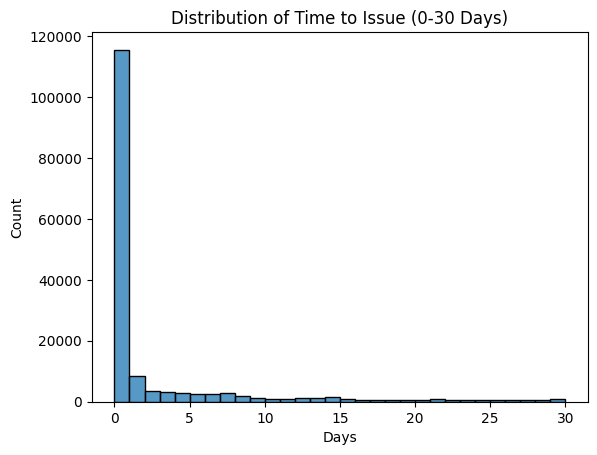

In [14]:

short_time = df_file[df_file['Time_to_Issue'].dt.days <= 30]['Time_to_Issue'].dt.days

sns.histplot(short_time, bins=30)
plt.title('Distribution of Time to Issue (0-30 Days)')
plt.xlabel('Days')
plt.savefig('Distribution of Time to Issue.png', bbox_inches='tight')
plt.show()

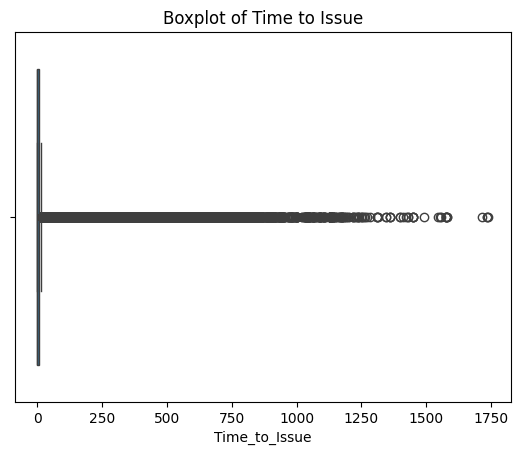

In [15]:
sns.boxplot(x=df_file['Time_to_Issue'].dt.days)
plt.title('Boxplot of Time to Issue')
plt.savefig('Boxplot of Time to Issue.png', bbox_inches='tight')
plt.show()

In [ ]:
# بنجمع البيانات حسب نوع التصريح وبنحسب متوسط عدد الأيام
permit_analysis = df_file.groupby('Permit Type Definition')['Time_to_Issue'].mean().dt.days

# بنرتب النتائج عشان نشوف الأبطأ فوق
print(permit_analysis.sort_values(ascending=False))  
# تفتكر السطر ده هيكمل إزاي لو عايزين نجمع التكلفة؟
cost_analysis = df_file.groupby('Permit Type Definition')['Estimated Cost'].sum()
print(cost_analysis.sort_values(ascending=False))

Permit Type Definition
new construction                       478
new construction wood frame            398
demolitions                            348
additions alterations or repairs       247
grade or quarry or fill or excavate     97
sign - erect                            52
wall or painted sign                    45
otc alterations permit                  10
Name: Time_to_Issue, dtype: int64
Permit Type Definition
new construction                       1.252963e+10
otc alterations permit                 6.720049e+09
additions alterations or repairs       5.963891e+09
new construction wood frame            1.838664e+09
grade or quarry or fill or excavate    6.260469e+07
demolitions                            4.351175e+07
sign - erect                           1.367108e+07
wall or painted sign                   1.762005e+06
Name: Estimated Cost, dtype: float64
